In [1]:
from pycollisiondb.pycollisiondb import PyCollision
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
pycoll = PyCollision()
# NB the default CollisioDB API URL is https://db-amdis.org/collisiondb/api/
# To use the official IAEA CollisionDB endpoint (when this is available) over-ride with:
#pycoll = PyCollision(DB_URL="https://amdis.iaea.org/db/collisiondb/")

In [10]:
pycoll.API_URL

'https://db-amdis.org/collisiondb/api/'

In [11]:
query = {'reactants': ['H+', 'H 1s'],
         'process_types': ['HIN'],
         'data_type': 'cross section'}
pycoll.query(**query)

'https://db-amdis.org/collisiondb/data/results/29703715-c9ba-4f7b-bcf1-107667860661.zip'

In [12]:
pycoll.download_datasets_archive_from_url()

PosixPath('/var/folders/vl/l2dy4k551j79g2n80pvjp4gw0000gn/T/tmp0h8bru7p/29703715-c9ba-4f7b-bcf1-107667860661.zip')

In [13]:
pycoll.unzip_dataset_archive()

PosixPath('/var/folders/vl/l2dy4k551j79g2n80pvjp4gw0000gn/T/tmp0h8bru7p/29703715-c9ba-4f7b-bcf1-107667860661')

In [16]:
# Get the manifest, repackage the DataSets into a dictionary keyed by DataSet ID
# and read the data files into memory.
pycoll.get_manifest()
pycoll.get_dataset_pks_by_reaction()
pycoll.read_all_datasets()

In [17]:
pycoll.datasets

{102737: D102737: H+ + H 1s → H+ + H+ + e-,
 107356: D107356: H+ + H 1s → H+ + H+ + e-,
 108169: D108169: H+ + H 1s → H+ + H+ + e-,
 103103: D103103: H 1s + H+ → H+ + H+ + e-,
 103104: D103104: H 1s + H+ → H+ + H+ + e-}

In [54]:
# Alternatively, just fetch all the datasets from the server over the API directly.

# Proton-impact ionization of H.
query = {'reactants': ['H+', 'H 1s'],
         'process_types': ['HIN'],
         'data_type': 'cross section'}
pycoll = PyCollision.get_datasets(query=query)

In [55]:
pycoll.datasets

{102737: D102737: H+ + H 1s → H+ + H+ + e-,
 107356: D107356: H+ + H 1s → H+ + H+ + e-,
 108169: D108169: H+ + H 1s → H+ + H+ + e-,
 103103: D103103: H 1s + H+ → H+ + H+ + e-,
 103104: D103104: H 1s + H+ → H+ + H+ + e-}

In [56]:
# Convert to atomic units.
pycoll.convert_units({'sigma': 'a02', 'E': 'E_h.u-1'})

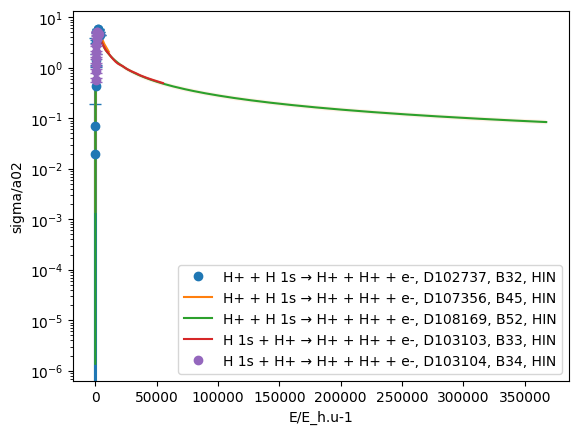

In [57]:
fig, ax = plt.subplots()
pycoll.plot_all_datasets(ax, label=('reaction', 'qid', 'refs', 'process_types'))
plt.legend()

In [58]:
# Pick a single DataSet and perform a unit conversion
ds = pycoll.datasets[103104]
ds.convert_units('sigma', 'Mb')
ds.convert_units('E', 'keV.u-1')

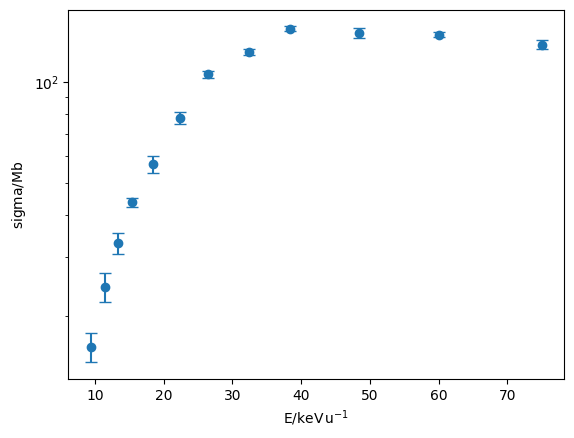

In [59]:
fig, ax = plt.subplots()
ds.plot_dataset(ax, label_axes=True, use_latex=True)